# Demo Experiment - Tutorial

> **IMPORTANT SETUP NOTE**  
> Before running the cells below, please ensure you have selected the correct **conda environment** (the one created for this project) as your kernel. 
> 
> If your editor (e.g., VS Code) prompts you to **"Install Jupyter kernel"** or **"Install ipykernel"**, please accept and install it. This is required to execute the Python code within the notebook.

### Experiment settings

Warnings ignore

In [1]:
import warnings
warnings.filterwarnings('ignore')

Model checkpoints settings & experiment names

All output files will be saved under the same base name, with an appropriate suffix depending on the performed action:

- ***name.mkv*** - orginal video with drawn keypoints
- ***name_adv.mkv*** - adversarial video with drawn keypoints
- ***results_name.json*** - keypoints from original video, 
- ***results_adv_name.json***- keypoints from adversarial video, 
- ***name_test.mkv*** - video with test results


In [2]:
import os
from pathlib import Path

# ID (NUMBER) of EXPERIMENT
exp_id = '0592' # <--- the video we want to analyze

# path to the input file we want to analyze
input_path = f"../penn-action-dataset/videos/{exp_id}-vis.mkv"
# original file name, which will be reused in subsequent steps
name = os.path.splitext(os.path.basename(input_path))[0]
print(f"Analyzed video: {name}")
# experiment folder name (to save tests on the same video in separate directories)
folder_exp_name = "experiment_"+name

# ========== Available models two-stage ========== 
# Model              |  Checkpoint                      |  Config 
# - ResNet50         |  ../checkpoints/res50.pth        |  ../configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_res50_8xb64-210e_coco-256x192.py
# - MobileNetV2      |  ../checkpoints/mobilenetv2.pth  |  ../configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_mobilenetv2_8xb64-210e_coco-256x192.py

# ========== Available models one-stage ========== 
# Model              |  Checkpoint                      |  Config 
# - YOLO-Pose M      |  ../checkpoints/yoloxpose_m.pth  |  ../configs/body_2d_keypoint/yoloxpose/coco/yoloxpose_m_8xb32-300e_coco-640.py
# - YOLO-Pose S      |  ../checkpoints/yoloxpose_s.pth  |  ../configs/body_2d_keypoint/yoloxpose/coco/yoloxpose_s_8xb32-300e_coco-640.py


# pose estimator settings
model_name = "ResNet50"
pose_est_cfg = "../configs/body_2d_keypoint/topdown_heatmap/coco/td-hm_res50_8xb64-210e_coco-256x192.py"   # <--- config
pose_est_ckpt = "../checkpoints/res50.pth"        # <--- checkpoint

# detector settings
detector_cfg = "../demo/mmdetection_cfg/faster_rcnn_r50_fpn_coco.py"
detector_ckpt = "../checkpoints/faster_rcnn_r50.pth"

# GROUND TRUTH from PENN-ACTION-DATASET
mat_kp_path_gt = f"../penn-action-dataset/labels/{exp_id}.mat"

# Is it trial (True = trial 25 frames)
trial = 'False'

Analyzed video: 0592-vis


This needs to be added if MMPose cannot be found or fails to run:


> 1. In the terminal, while active in your conda environment, run:<br>
            `python -c "import mmpose; print(mmpose.__file__);"`

Provide the obtained path in `sys.path.append()`, EXCLUDING `/mmpose/__init__.py`


In [3]:
import sys
sys.path.append("C:/example_path/OKS_attack") # <--- path

import mmpose
print(mmpose.__version__)

1.3.2


### Original video

Variable settings for pose estimator

In [4]:
# script path
script = "../demo/topdown_demo_with_mmdet_clean.py"

# output folder (for saving results) with an 'og' subfolder for original detection results
output_folder_og = f"../experiments/{folder_exp_name}/og"

▶️ **Run pose estimator**

In [5]:
script_name = os.path.splitext(os.path.basename(script))[0]
print(f"Running {script_name} for {name} video...")
print(f"="*80+"\n")

%run {script} {detector_cfg} {detector_ckpt} {pose_est_cfg} {pose_est_ckpt} --input {input_path} --output-root {output_folder_og} --save-predictions --trial {trial} --gt {mat_kp_path_gt}

Running topdown_demo_with_mmdet_clean for 0592-vis video...



x:\miniconda3\envs\mgr\lib\site-packages\mmengine\optim\optimizer\zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \



[INFO] Setting global random seed to: 42

Loads checkpoint by local backend from path: ../checkpoints/faster_rcnn_r50.pth
Loads checkpoint by local backend from path: ../checkpoints/res50.pth

===== RUNNING FULL VIDEO (47 frames) =====
predictions have been saved at ../experiments/experiment_0592-vis/og/results_0592-vis.json
08/31 14:47:13 - mmengine - INFO - the output video has been saved at ../experiments/experiment_0592-vis/og\0592-vis.mkv


Displaying the **original** video

In [14]:
import cv2

video_test_path = f"../experiments/{folder_exp_name}/og/{name}.mkv"

# Load the video
cap = cv2.VideoCapture(video_test_path)

print("Playing video in a loop... (Press 'Q' in the window to close)")

while cap.isOpened():
    ret, frame = cap.read()
    
    # If ret is False, the video has ended
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue
        
    # Display the frame in a new window
    cv2.imshow('Original video (Press Q to exit)', frame)
    
    # Playback speed control (waitKey in milliseconds)
    # Standard 30 FPS requires ~30ms. (can use 60 for 0.5 slow)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# Release resources and close the window
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

Playing video in a loop... (Press 'Q' in the window to close)


-1

### OKS Attack

Variable settings for pose estimator & attack

In [6]:
# script path
script_at = "../attacks/OKS_attack_det.py"

# output folder (for saving results) with an 'adv' subfolder for adversarial detection results
output_folder_at = f"../experiments/{folder_exp_name}/adv"

# target keypoints (keypoints saved in .json file)
target_kpt_at = f"../experiments/{folder_exp_name}/og/results_{name}.json"

▶️ **Run OKS Attack**

In [7]:
script_name_at = os.path.splitext(os.path.basename(script_at))[0]
print(f"Running {script_name_at} for {name} video...")
print(f"="*80+"\n")

# with detector
%run {script_at} {detector_cfg} {detector_ckpt} {pose_est_cfg} {pose_est_ckpt} --input {input_path} --output-root {output_folder_at} --save-predictions --target-keypoints {target_kpt_at} --trial {trial} --gt {mat_kp_path_gt}

# without detector (ablation study)
# %run {script_at} {pose_est_cfg} {pose_est_ckpt} --input {input_path} --output-root {output_folder_at} --save-predictions --target-keypoints {target_kpt_at} --trial {trial}

Running OKS_attack_det for 0592-vis video...


[INFO] Setting global random seed to: 42

BBOX based on ground truth .mat

08/31 14:47:13 - mmengine - WARNING - The current default scope "mmpose" is not "mmdet", `init_default_scope` will force set the currentdefault scope to "mmdet".
Loads checkpoint by local backend from path: ../checkpoints/faster_rcnn_r50.pth
08/31 14:47:14 - mmengine - WARNING - The current default scope "mmdet" is not "mmpose", `init_default_scope` will force set the currentdefault scope to "mmpose".
Loads checkpoint by local backend from path: ../checkpoints/res50.pth

===== RUNNING FULL VIDEO (47 frames) =====
[1/47] processing frame
  [INITIAL] Start | score: 0.9814 | rmse: 2.000001
        [ORTHOGONAL] cand 1 | score: 0.9678 | delta: 10.0000
        [ORTHOGONAL] cand 2 | score: 0.9335 | delta: 10.0000
        [ORTHOGONAL] cand 3 | score: 0.9928 | delta: 10.0000
        [ORTHOGONAL] cand 4 | score: 0.9645 | delta: 10.0000
        [ORTHOGONAL] cand 5 | score: 0.9

Displaying the **adversarial** video

In [15]:
import cv2

video_test_path = f"../experiments/{folder_exp_name}/adv/{name}_adv.mkv"

# Load the video
cap = cv2.VideoCapture(video_test_path)

print("Playing video in a loop... (Press 'Q' in the window to close)")

while cap.isOpened():
    ret, frame = cap.read()
    
    # If ret is False, the video has ended
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue
        
    # Display the frame in a new window
    cv2.imshow('Adversarial video (Press Q to exit)', frame)
    
    # Playback speed control (waitKey in milliseconds)
    # Standard 30 FPS requires ~30ms. (can use 60 for 0.5 slow)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# Release resources and close the window
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

Playing video in a loop... (Press 'Q' in the window to close)


-1

### Tests

#### Test 1 - Visualizing differences

Overlaying two skeletons on a single video for comparison:

- original skeleton - green
- adversarial skeleton - red

In [8]:
# script path
test_script_1 = "../oks_tools/visualization.py" 
# path to the original video for result visualization
video_path = input_path
# path to the keypoints BEFORE the attack
org_kpts_path = f"../experiments/{folder_exp_name}/og/results_{name}.json"
# path to the keypoints AFTER the attack
adv_kpts_path = f"../experiments/{folder_exp_name}/adv/results_adv_{name}.json"
# path to the output folder where the test video will be saved
output_test_path = f"../experiments/{folder_exp_name}/results"
# thickness of points and lines for the drawn keypoints
point = 5
line = 1

▶️ **Run visualizing differences script**

In [9]:
%run {test_script_1} --video {video_path} --org_keypoints {org_kpts_path} --adv_keypoints {adv_kpts_path} --output_path {output_test_path} --point {point} --line {line}


[INFO] Setting global random seed to: 42

Created visualization of original (green) vs adversarial (red) keypoints in ..\experiments\experiment_0592-vis\results\0592-vis_test.mkv.



Displaying the **comparison** video

In [18]:
import cv2

video_test_path = f"../experiments/{folder_exp_name}/results/{name}_test.mkv"

# Load the video
cap = cv2.VideoCapture(video_test_path)

print("Playing video in a loop... (Press 'Q' in the window to close)")

while cap.isOpened():
    ret, frame = cap.read()
    
    # If ret is False, the video has ended
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        continue
        
    # Display the frame in a new window
    cv2.imshow('Comparison video (Press Q to exit)', frame)
    
    # Playback speed control (waitKey in milliseconds)
    # Standard 30 FPS requires ~30ms. (can use 60 for 0.5 slow)
    if cv2.waitKey(30) & 0xFF == ord('q'):
        break

# Release resources and close the window
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

Playing video in a loop... (Press 'Q' in the window to close)


-1

#### Test 2 - Accuracy

Calculating the mean OKS across all frames compared to the **ground truth** from the Penn Action dataset

In [10]:
# script path
test_script_2 = '../oks_tools/measures.py'

# paths to the JSON files containing keypoints
gt_kp = mat_kp_path_gt  # ground truth
org_kp = f'../experiments/{folder_exp_name}/og/results_{name}.json'       # original results
adv_kp = f'../experiments/{folder_exp_name}/adv/results_adv_{name}.json'  # adversarial results

output_folder_path = f'../experiments/{folder_exp_name}/results'

▶️ **Run accuracy script**


[INFO] Setting global random seed to: 42


Calculating OKS_score for the original video...
RESULT: 0.73

Calculating OKS_score for the adversarial video...
RESULT: 0.35

+---------------------+----------------+------------+---------------+
| Test                | Measure        | Original   | Adversarial   |
+=====================+================+============+===============+
|                     | Mean OKS score | 0.73       | 0.35          |
+---------------------+----------------+------------+---------------+
| ResNet50            | Losses         | 4          | 25            |
+---------------------+----------------+------------+---------------+
| experiment_0592-vis |                |            |               |
+---------------------+----------------+------------+---------------+
|                     | Difference     |            | 0.38          |
+---------------------+----------------+------------+---------------+
Table saved as results.png!


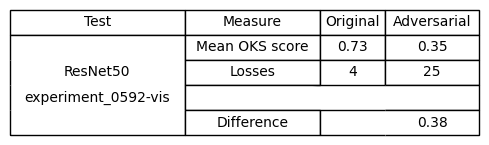

In [11]:
%run {test_script_2} --ground {gt_kp} --test_org {org_kp} --test_adv {adv_kp} --output {output_folder_path} --model {model_name} --test {folder_exp_name}

#### Test 3 - Action Recognition

Action recognition on original and adversarial video for predictions comparison

In [12]:
gt_kp = mat_kp_path_gt  # ground truth
org_kp_ar = f'../experiments/{folder_exp_name}/og'       # original results
adv_kp_ar = f'../experiments/{folder_exp_name}/adv'  # adversarial results
output_ar = f'../experiments/{folder_exp_name}/results'

▶️ **Run action recognition**


[INFO] Setting global random seed to: 42

Running Action Recognition for experiment_0592-vis
Loads checkpoint by local backend from path: ../mmaction2/checkpoints/slowonly_r50_k400-keypoint.pth

Found JSON file: results_0592-vis

Performing action recognition for results_0592-vis...

--- SUCCESS ---

Top 1: Class 31 - bowling | 93.53%
Top 2: Class 358 - throwing discus | 3.71%
Top 3: Class 174 - kicking field goal | 0.74%
Loads checkpoint by local backend from path: ../mmaction2/checkpoints/slowonly_r50_k400-keypoint.pth

Found JSON file: results_adv_0592-vis

Performing action recognition for results_adv_0592-vis...

--- SUCCESS ---

Top 1: Class 31 - bowling | 76.44%
Top 2: Class 92 - disc golfing | 10.11%
Top 3: Class 48 - catching or throwing baseball | 3.82%

+-------------+------------+---------+--------------+--------------+
| Video       |   Class ID | Class   | Confidence   | Difference   |
+=============+============+=========+==============+==============+
| Original    |  

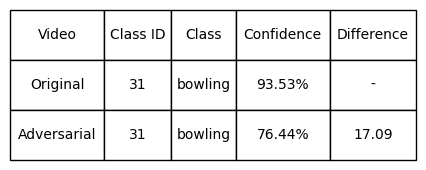

In [13]:
%run ../oks_tools/action_recognition.py --og-kpts {org_kp_ar} --adv-kpts {adv_kp_ar} --output {output_ar} --exp {folder_exp_name}